In [1]:
import torch

# Sprawdź, czy PyTorch wykrywa GPU
if torch.cuda.is_available():
    print("PyTorch widzi GPU!")
    print(f"Nazwa karty graficznej: {torch.cuda.get_device_name(0)}")
    print(f"Liczba dostępnych GPU: {torch.cuda.device_count()}")
else:
    print("PyTorch nie widzi GPU.")


PyTorch widzi GPU!
Nazwa karty graficznej: NVIDIA GeForce GTX 960
Liczba dostępnych GPU: 1


In [2]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "max_split_size_mb:128"

In [2]:
import torch
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()
torch.cuda.reset_accumulated_memory_stats()
torch.cuda.synchronize()
torch.cuda.empty_cache()

In [2]:
cd /tf/Inzynierka

/tf/Inzynierka


In [3]:
from ultralytics import YOLO

# Create a new YOLO model from scratch

# Load a pretrained YOLO model (recommended for training)
model = YOLO("yolo11n.pt")

# Train the model using the 'data.yaml' dataset for 20 epochs
results = model.train(data="/tf/Inzynierka/yolov8_3klasy_calosc_przejrzana/data.yaml", epochs=50, batch=4)

# Evaluate the model's performance on the validation set
results = model.val()

results = model.val(split="test")

# Perform object detection on an image using the model
results = model("/tf/Inzynierka/yolov8_3klasy_calosc_przejrzana/test/images/20241119_155900_4_jpg.rf.df5677423eeedfb64a949296071010b8.jpg")

# Export the model to ONNX format
success = model.export(format="onnx")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
New https://pypi.org/project/ultralytics/8.3.51 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.33 🚀 Python-3.8.10 torch-2.4.1+cu121 CUDA:0 (NVIDIA GeForce GTX 960, 1986MiB)
engine/trainer: task=detect, mode=train, model=yolo11n.pt, data=/tf/Inzynierka/yolov8_3klasy_calosc_przejrzana/data.yaml, epochs=50, time=None, patience=100, batch=4, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train12, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_

100%|██████████| 22.2M/22.2M [00:00<00:00, 59.1MB/s]


Overriding model.yaml nc=80 with nc=3

                   from  n    params  module                                       arguments                     
  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 
  1                  -1  1      4672  ultralytics.nn.modules.conv.Conv             [16, 32, 3, 2]                
  2                  -1  1      6640  ultralytics.nn.modules.block.C3k2            [32, 64, 1, False, 0.25]      
  3                  -1  1     36992  ultralytics.nn.modules.conv.Conv             [64, 64, 3, 2]                
  4                  -1  1     26080  ultralytics.nn.modules.block.C3k2            [64, 128, 1, False, 0.25]     
  5                  -1  1    147712  ultralytics.nn.modules.conv.Conv             [128, 128, 3, 2]              
  6                  -1  1     87040  ultralytics.nn.modules.block.C3k2            [128, 128, 1, True]           
  7                  -1  1    295424  ultralytics

train: Scanning /tf/Inzynierka/yolov8_3klasy_calosc_przejrzana/train/labels.cache... 1881 images, 0 backgrounds, 0 corrupt: 100%|██████████| 1881/1881 [00:00<?, ?it/s]

WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 143, len(boxes) = 29668. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.


...

                   all        616      10931      0.851      0.777      0.854      0.532
         układ_scalony        285        816      0.819      0.702      0.813      0.617
           kondensator        502       4665      0.861      0.824      0.878      0.518
               opornik        561       5450      0.873      0.804       0.87      0.462
Speed: 0.6ms preprocess, 11.2ms inference, 0.0ms loss, 1.0ms postprocess per image
Results saved to runs/detect/train122
Ultralytics 8.3.33 🚀 Python-3.8.10 torch-2.4.1+cu121 CUDA:0 (NVIDIA GeForce GTX 960, 1986MiB)


val: Scanning /tf/Inzynierka/yolov8_3klasy_calosc_przejrzana/test/labels.cache... 269 images, 0 backgrounds, 0 corrupt: 100%|██████████| 269/269 [00:00<?, ?it/s]

WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 8, len(boxes) = 2934. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.



                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 68/68 [00:04<00:00, 14.05it/s]


                   all        269       2934      0.819      0.734      0.799      0.522
         układ_scalony         88        213      0.806      0.789      0.865       0.69
           kondensator        210       1425      0.827      0.774      0.813      0.511
               opornik        195       1296      0.824      0.638      0.719      0.365
Speed: 0.5ms preprocess, 11.4ms inference, 0.0ms loss, 1.6ms postprocess per image
Results saved to runs/detect/train123

image 1/1 /tf/Inzynierka/yolov8_3klasy_calosc_przejrzana/test/images/20241119_155900_4_jpg.rf.df5677423eeedfb64a949296071010b8.jpg: 640x640 5 kondensators, 11.6ms
Speed: 1.6ms preprocess, 11.6ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)
Ultralytics 8.3.33 🚀 Python-3.8.10 torch-2.4.1+cu121 CPU (Intel Core(TM) i5-4460  3.20GHz)

PyTorch: starting from 'runs/detect/train12/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 7, 8400) (5.2 MB)
requirements: Ultralytics re

In [7]:
results = model.val(split="test")

Ultralytics 8.3.33 🚀 Python-3.8.10 torch-2.4.1+cu121 CUDA:0 (NVIDIA GeForce GTX 960, 1986MiB)
Model summary (fused): 168 layers, 3,006,233 parameters, 13,065 gradients, 8.1 GFLOPs


val: Scanning /mnt/Inzynierka/yolov8_3klasy_calosc_przejrzana/test/labels... 269 images, 0 backgrounds, 0 corrupt: 100%|██████████| 269/269 [00:00<00:00, 1419.51it/s]

val: New cache created: /mnt/Inzynierka/yolov8_3klasy_calosc_przejrzana/test/labels.cache


WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 8, len(boxes) = 2934. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 68/68 [00:04<00:00, 14.67it/s]


                   all        269       2934     0.0468     0.0283    0.00926    0.00202
                     0         88        213     0.0593     0.0376    0.00787    0.00143
                     1        210       1425     0.0174     0.0119    0.00432    0.00136
                     2        195       1296     0.0637     0.0355     0.0156    0.00326
Speed: 0.6ms preprocess, 10.7ms inference, 0.0ms loss, 2.5ms postprocess per image
Results saved to runs/detect/train83


In [8]:
results = model(["/mnt/Inzynierka/yolov8_3klasy_calosc_przejrzana/test/images/20241119_160121_2_jpg.rf.11b9993f85191bf5170b10aeb8636aed.jpg", "/mnt/Inzynierka/yolov8_3klasy_calosc_przejrzana/test/images/20241119_160121_3_jpg.rf.eee8fef01d9a1ada49581ff4495665f2_rot270_blurred.jpg"])


0: 640x640 1 0, 2 2s, 20.1ms
1: 640x640 2 2s, 20.1ms
Speed: 5.4ms preprocess, 20.1ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 640)


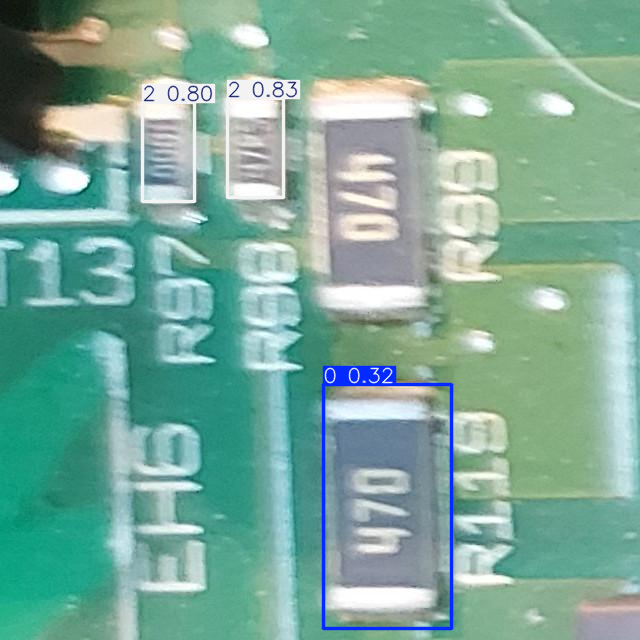

In [9]:
results[0].show()

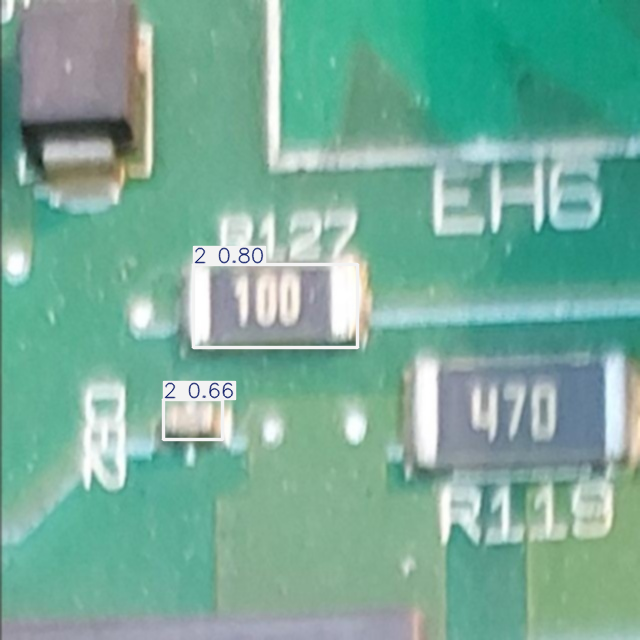

In [10]:
results[1].show()

In [8]:
results.extend(model(["/mnt/Inzynierka/yolov8_3klasy_z_dodatkami/test/images/20241119_155900_4_jpg.rf.df5677423eeedfb64a949296071010b8.jpg"]))


0: 640x640 4 kondensators, 1 opornik, 12.9ms
Speed: 2.3ms preprocess, 12.9ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)


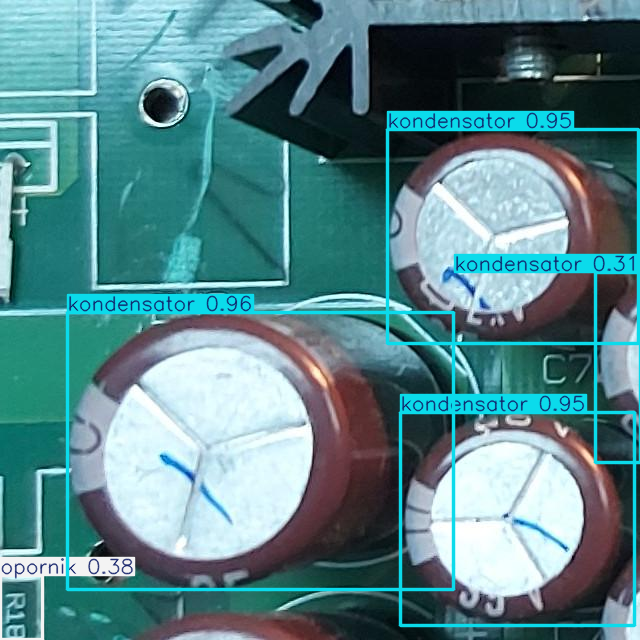

In [9]:
results[2].show()

In [10]:
results.extend(model(["/mnt/Inzynierka/yolov8_3klasy_z_dodatkami/test/images/PCBA_67_jpg.rf.7cfeb785270e623dcbe3132f90f8f5f7.jpg","/mnt/Inzynierka/yolov8_3klasy_z_dodatkami/test/images/PCBA_97_jpg.rf.875a2f4b2e2c0c0bbcab0a6c98b7805f.jpg"]))


0: 640x640 3 kondensators, 10 oporniks, 11.0ms
1: 640x640 5 uklad_scalonys, 9 kondensators, 18 oporniks, 11.0ms
Speed: 2.2ms preprocess, 11.0ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 640)


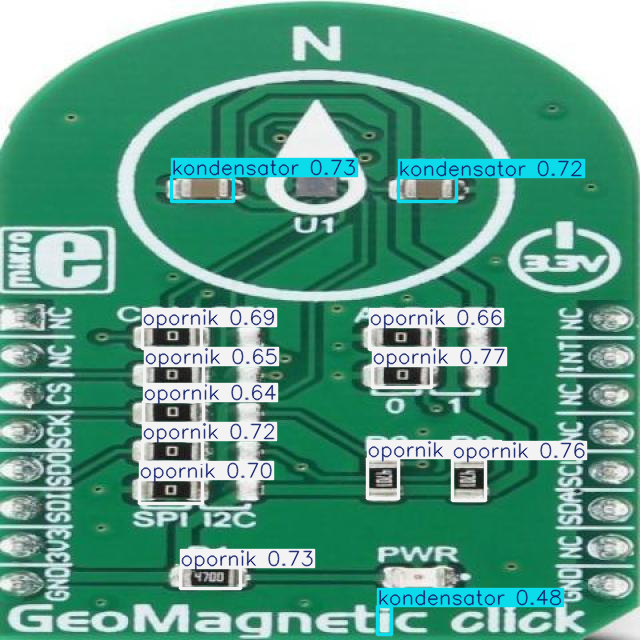

In [11]:
results[3].show()

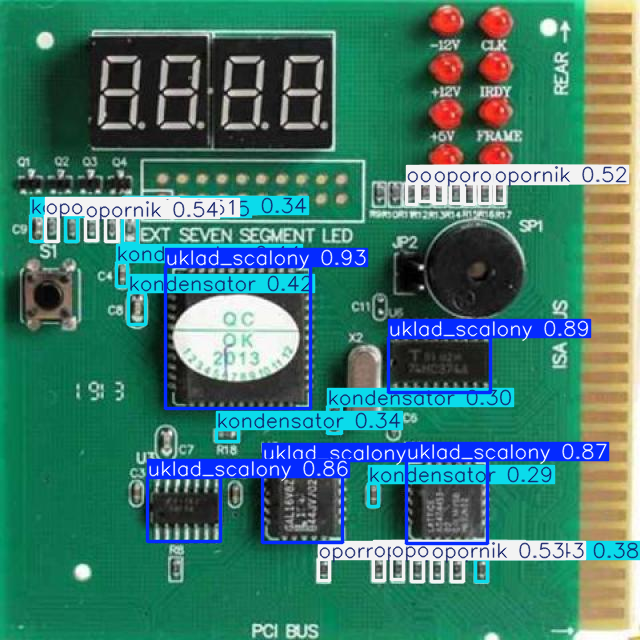

In [12]:
results[4].show()